## Advanced Usage Demo: Cell type deconvolution NPC1 --> NPC2 with rare cell types in the reference 

### Key APIs
- expDeconv

### I. ST to ST Deconvolution
The default expDeconv setting is generalizable to many types of data. However, when translating cell types from ST reference to ST data, it may be worth trying the proportion-based mapping since the expressions of reference and target data are at the same scale. We can hence set the temperature parameter `tau` to be a non-None value, to turn on the proportion mapping mode. 

- `tau` is the temperature term applied to softmax normalization (making the mapping matrix a proportion matrix), when `tau=1`, it is standard softmax, when `tau<1`, the mapping proportion matrix would be less evenly distributed and become more sparse.

- if the cell type distribution of the reference data is supposed to be consistent with the target (like in this example), we can use   `calibrate` to prunning out less confident over-predicted cell types.

- If there are rare cell types in the reference, we can turn on `smart_markers` mode in selecting marker genes. It uses standard wilcoxon statistics to derive markers for common cell types, and special metrics to select markers for rare cell types (e.g., cell types with <= 20 cells)

```python
_, weight = expDeconv(
            adata_ref=ref_adata,
            adata_tgt=NPC2,
            label_key='Celltype',
            seed=seed,
            topk=10, 
            tau=1.0,
            calibrate=0.6,
            smart_markers=True,
            device=device
            ) 
```
```

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from transpa.util import leiden_cluster, expDeconv, select_deconv_genes
import torch
import warnings 

warnings.filterwarnings('ignore')

seed = 10
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
# load preprocessed scRNA-seq and spatial datasets
NPC1_PATH = 'NPC1.h5ad'
NPC2_PATH = 'NPC2.h5ad'
NPC1 = sc.read_h5ad(NPC1_PATH)
NPC2 = sc.read_h5ad(NPC2_PATH)
NPC1, NPC2

(AnnData object with n_obs × n_vars = 1331 × 36601
     obs: 'array_row', 'array_col', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'in_tissue', 'pxl_row_in_fullres_old', 'pxl_col_in_fullres_old', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'total RNA counts', 'B', 'Myeloid', 'T', 'Treg', 'fibroblast', 'normal', 'tumor', 'Celltype'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'spatial'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 1089 × 36601
     obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_coun

The following code prepares input for expDeconv, it
- filters SC types with less than 2 samples, 
- select top cell-type marker genes as training candidate,
- align training & testing genes
- prepare cell cluster labels and annotations


In [2]:
NPC2 = NPC2[:, (NPC2.X.sum(axis=0) > 0)].copy()
NPC1 = NPC1[:, (NPC1.X.sum(axis=0) > 0 )].copy()

sc.pp.highly_variable_genes(NPC2, n_top_genes=5000,  flavor='seurat_v3')
NPC2 = NPC2[:, NPC2.var.highly_variable].copy()

sc.pp.highly_variable_genes(NPC1, n_top_genes=5000,  flavor='seurat_v3')
NPC1 = NPC1[:, NPC1.var.highly_variable].copy()

shared_genes = np.intersect1d(NPC2.var_names, NPC1.var_names)
HybISS = NPC2[:, shared_genes]
NPC1 = NPC1[:, shared_genes]

In [3]:
sc.pp.pca(HybISS, n_comps=30)
celltype_counts = NPC1.obs['Celltype'].value_counts()

celltype_drop = celltype_counts.index[celltype_counts < 2]
ref_adata = NPC1.copy()
if len(celltype_drop):
    print(f'Drop celltype {list(celltype_drop)} (contain less 2 samples)')
    ref_adata = NPC1[~NPC1.obs['Celltype'].isin(celltype_drop),].copy()

classes = ref_adata.obs.Celltype.values
ct_list = np.unique(classes)

- Run the main cell type deconvoluation method
- Normalize result and select the top1 cell type


In [4]:
_, weight = expDeconv(
            adata_ref=ref_adata,
            adata_tgt=NPC2,
            label_key='Celltype',
            seed=seed,
            topk=10, 
            tau=1.0, 
            calibrate=0.6, 
            smart_markers=True,
            device=device
            ) 
df_results = pd.DataFrame(weight, columns=ct_list)

df_results = (df_results.T/df_results.sum(axis=1)).T

NPC2.obs['Class'] = df_results.columns[np.argmax(df_results.values, axis=1)]

[expDeconv] 1331 ref cells, 1089 tgt spots, 7 cell types, 2208 shared genes
[expDeconv] Auto-detected raw counts: True
[expDeconv] Selected 66 marker genes (topk=10, 7 cell types)
[expDeconv] Leiden clustering: 8 clusters
[expDeconv] Augmented target with cluster means -> 1097 total rows (1089 original spots)
[expDeconv] Score-init weights computed (1097 spots x 7 cell types)
[expDeconv] Starting fit_deconv (n_epochs=8000, lr=0.01, wd=0.001, wt_js=2.0)
  [fit_deconv] Epoch 1000/8000, loss: 786.648682
  [fit_deconv] Epoch 2000/8000, loss: 784.860657
  [fit_deconv] Epoch 3000/8000, loss: 784.407776
  [fit_deconv] Epoch 4000/8000, loss: 784.225159
  [fit_deconv] Epoch 5000/8000, loss: 784.135193
  [fit_deconv] Epoch 6000/8000, loss: 784.088989
  [fit_deconv] Epoch 7000/8000, loss: 784.069763
  [fit_deconv] Epoch 8000/8000, loss: 784.066101
[expDeconv] Training complete
[expDeconv] Prediction done: 1097 spots x 66 cell types


Following code for diagnosis and evaluation

  Evaluation: Predicted 'Class' vs Observed 'Celltype'
  Accuracy          : 0.7521
  F1  (macro)       : 0.5029
  F1  (weighted)    : 0.7711
  Precision (macro) : 0.4650
  Recall    (macro) : 0.5819

Per-class report:
              precision    recall  f1-score   support

           B       0.96      0.71      0.81       615
     Myeloid       0.35      0.54      0.42        59
           T       0.04      0.10      0.06        20
        Treg       0.25      0.50      0.33         4
  fibroblast       0.58      0.86      0.70        96
      normal       0.29      0.44      0.35         9
       tumor       0.78      0.92      0.84       286

    accuracy                           0.75      1089
   macro avg       0.46      0.58      0.50      1089
weighted avg       0.82      0.75      0.77      1089



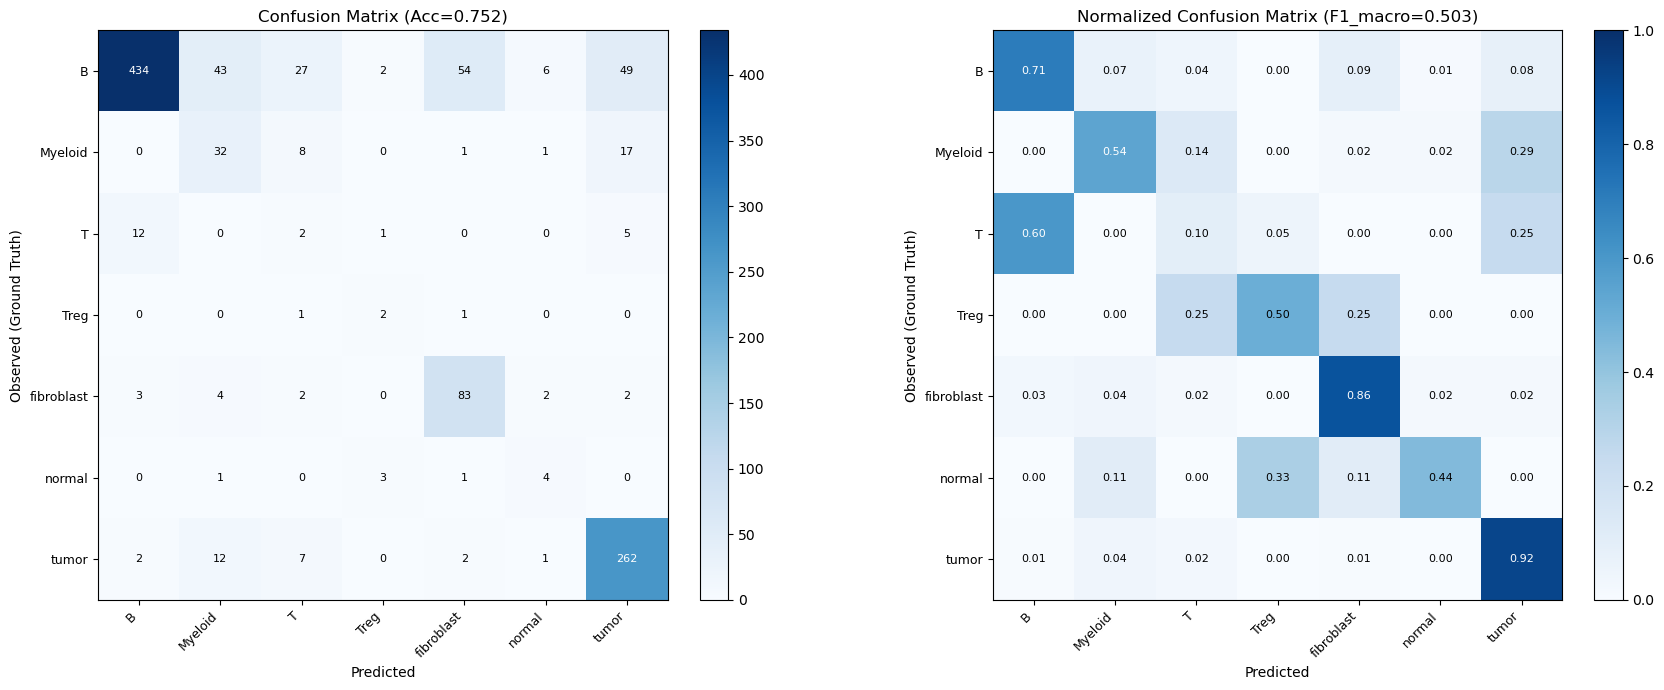

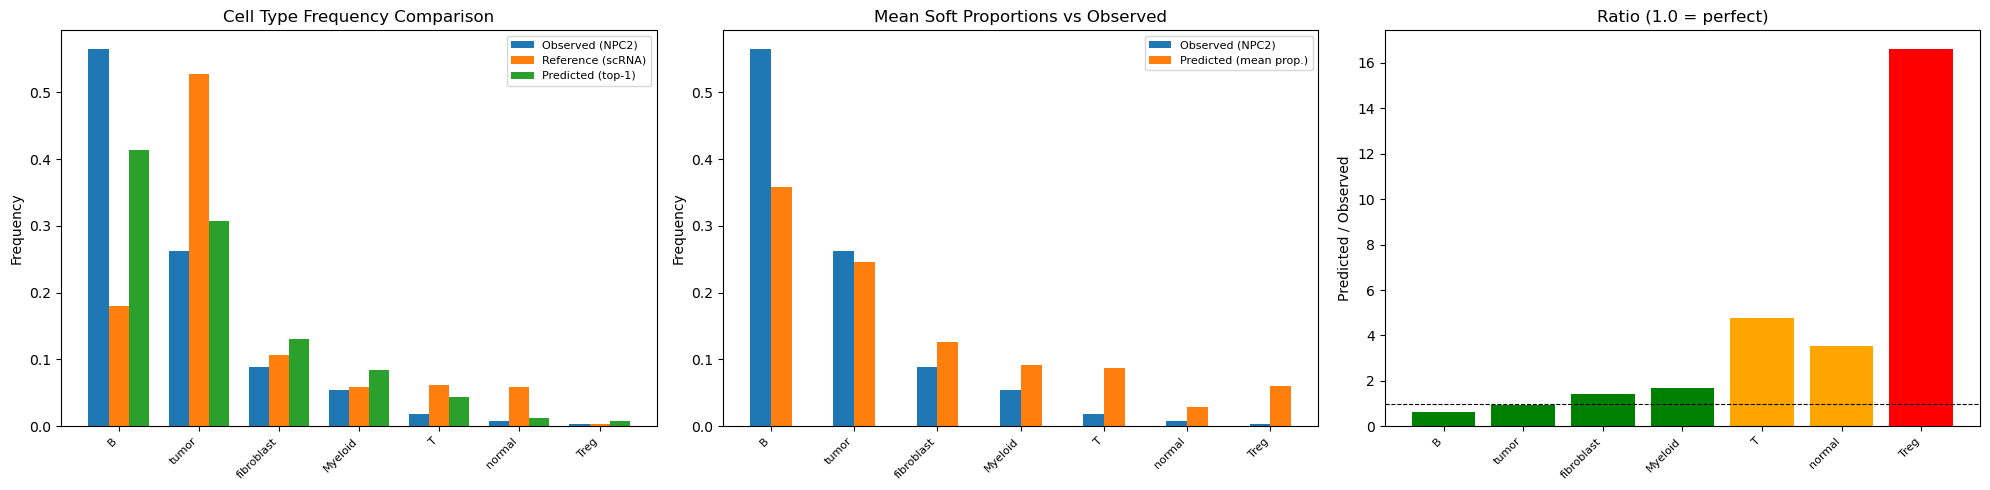

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)

y_true = NPC2.obs['Celltype'].values.astype(str)
y_pred = NPC2.obs['Class'].values.astype(str)

all_labels = sorted(set(y_true) | set(y_pred))

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, labels=all_labels, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, labels=all_labels, average='weighted', zero_division=0)
prec_macro = precision_score(y_true, y_pred, labels=all_labels, average='macro', zero_division=0)
rec_macro = recall_score(y_true, y_pred, labels=all_labels, average='macro', zero_division=0)

print("=" * 60)
print("  Evaluation: Predicted 'Class' vs Observed 'Celltype'")
print("=" * 60)
print(f"  Accuracy          : {acc:.4f}")
print(f"  F1  (macro)       : {f1_macro:.4f}")
print(f"  F1  (weighted)    : {f1_weighted:.4f}")
print(f"  Precision (macro) : {prec_macro:.4f}")
print(f"  Recall    (macro) : {rec_macro:.4f}")
print("=" * 60)

print("\nPer-class report:")
print(classification_report(y_true, y_pred, labels=all_labels, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=all_labels)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(all_labels)))
ax.set_yticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_labels, fontsize=9)
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed (Ground Truth)')
ax.set_title(f'Confusion Matrix (Acc={acc:.3f})')
for i in range(len(all_labels)):
    for j in range(len(all_labels)):
        val = cm[i, j]
        color = 'white' if val > cm.max() / 2 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(all_labels)))
ax.set_yticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_labels, fontsize=9)
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed (Ground Truth)')
ax.set_title(f'Normalized Confusion Matrix (F1_macro={f1_macro:.3f})')
for i in range(len(all_labels)):
    for j in range(len(all_labels)):
        val = cm_norm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

ref_counts = pd.Series(classes).value_counts()
ref_freq = (ref_counts / ref_counts.sum()).sort_index()

pred_top1 = NPC2.obs['Class'].value_counts()
pred_freq = (pred_top1 / pred_top1.sum()).reindex(ref_freq.index, fill_value=0)

obs_counts = pd.Series(y_true).value_counts()
obs_freq = (obs_counts / obs_counts.sum()).sort_index()

pred_mean_prop = df_results.mean(axis=0).sort_index()
pred_mean_prop = pred_mean_prop / pred_mean_prop.sum()

ct_order = obs_freq.sort_values(ascending=False).index

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(len(ct_order))
w = 0.25

ax = axes[0]
ax.bar(x - w, obs_freq.reindex(ct_order, fill_value=0), w, label='Observed (NPC2)')
ax.bar(x,     ref_freq.reindex(ct_order, fill_value=0), w, label='Reference (scRNA)')
ax.bar(x + w, pred_freq.reindex(ct_order, fill_value=0), w, label='Predicted (top-1)')
ax.set_xticks(x)
ax.set_xticklabels(ct_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Frequency')
ax.set_title('Cell Type Frequency Comparison')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x - w/2, obs_freq.reindex(ct_order, fill_value=0), w, label='Observed (NPC2)')
ax.bar(x + w/2, pred_mean_prop.reindex(ct_order, fill_value=0), w, label='Predicted (mean prop.)')
ax.set_xticks(x)
ax.set_xticklabels(ct_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Frequency')
ax.set_title('Mean Soft Proportions vs Observed')
ax.legend(fontsize=8)

ax = axes[2]
obs_reindexed = obs_freq.reindex(ct_order, fill_value=0)
pred_reindexed = pred_mean_prop.reindex(ct_order, fill_value=0)
ratio = (pred_reindexed / (obs_reindexed + 1e-10)).values
colors = ['green' if 0.5 < r < 2.0 else 'orange' if 0.2 < r < 5.0 else 'red'
          for r in ratio]
ax.bar(x, ratio, color=colors)
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ct_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Predicted / Observed')
ax.set_title('Ratio (1.0 = perfect)')

plt.tight_layout()
plt.show()

#### Plot the deconvolution result

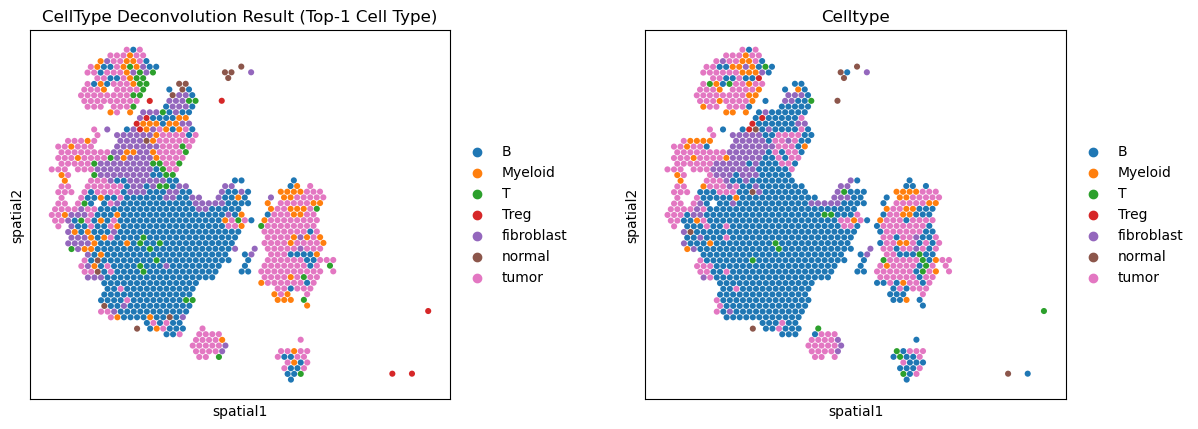

In [6]:
NPC2.obsm['spatial'] = NPC2.obsm['spatial'] * np.array([[1, -1]])
sc.pl.spatial(NPC2, color=['Class', "Celltype"],img_key=None, title="CellType Deconvolution Result (Top-1 Cell Type)", spot_size=200.0)